In [1]:
import pandas as pd
import logging
import re

In [314]:
pcn_file = pd.read_excel("excel_files/PCN_Data.xlsx")
pcn_file.shape

(56302, 5)

In [3]:
pcn_data = pcn_file.rename(columns={
    "County":"county",
    "Subcounties":"subcounty",
    "Unnamed: 2":"community_1",
    "Unnamed: 3":"community_facilities",
    "Unnamed: 4":"community_2"
})
pcn_data.head()

,county,subcounty,community_1,community_facilities,community_2
0,Uasin Gishu County,NaN,NaN,NaN,NaN
1,NaN,"1. Ainabkoi Sub County [Males: 77,429 Females:...",NaN,NaN,NaN
2,NaN,Main hub : Burnt Forest Sub County Hospital (L...,NaN,NaN,NaN
3,NaN,Level 3/2 Hub/Spoke,NaN,Level Spoke & Community Health Unit,NaN
4,NaN,"Lifecare Hospital, Eldoret , [Level 4] ,Owner:...",NaN,NaN,NaN


In [4]:
pcn_counties = pcn_data["county"].dropna()

## County Mapping

In [5]:
pcn_counties.to_csv("Counties.csv")
pcn_counties

0            Uasin Gishu County
511              Kericho County
1394               Nandi County
2218               Siaya County
3755             Turkana County
4184            Machakos County
5912              Migori County
6649             Garissa County
7132             Mandera County
7902             Baringo County
8685               Kisii County
9959               Bomet County
10430            Nyamira County
13274            Bungoma County
14129              Busia County
14700         Tana River County
14855           Kakamega County
16021               Meru County
18461            Mombasa County
19785        Trans Nzoia County
20574      Tharaka Nithi County
21791            Nairobi County
28201              Wajir County
28557             Vihiga County
29443             Kilifi County
30374             Isiolo County
30519            Muranga County
31747             Kiambu County
34950             Nakuru County
37072           Homa Bay County
41798         West Pokot County
42159   

In [6]:
pcn_counties.shape

(47,)

### SubCounty Mapping

In [7]:
pcn_subcounties = pcn_data["subcounty"].dropna()

In [304]:
pattern_sub_counties = r'Males'
sub_counties = pcn_subcounties[pcn_subcounties.str.contains(pattern_sub_counties)==True]
sub_counties.to_csv("subcounty.csv")
sub_counties

1        1. Ainabkoi Sub County [Males: 77,429 Females:...
143      2. Kapseret Sub County [Males: 116,638 Females...
235      3. Kesses Sub County [Males: 75,263 Females: 7...
309      4. Moiben Sub County [Males: 101,613 Females: ...
318      5. Soy Sub County [Males: 128,332 Females: 131...
                               ...                        
55784    311. Transmara East Sub County [Males: 63,679 ...
55837    312. Transmara West Sub County [Males: 141,359...
55954    313. Samburu Central Sub County [Males: 95,356...
56116    314. Samburu East Sub County [Males: 45,087 Fe...
56209    315. Samburu North Sub County [Males: 39,051 F...
Name: subcounty, Length: 315, dtype: object

### Main Hub Mapping

In [9]:
pattern_main_hub = r'Main hub'
main_hub = pcn_subcounties[pcn_subcounties.str.contains(pattern_main_hub)==True]
main_hub.to_csv("main_hub.csv")
main_hub

2        Main hub : Burnt Forest Sub County Hospital (L...
144      Main hub : Pioneer Health Centre (Level 3) Own...
236      Main hub : Chepkigen Health Centre (Level 3) O...
310      Main hub : Uasin Gishu District Hospital (Leve...
319      Main hub : Ziwa Sub County Hospital (Level 4) ...
                               ...                        
55785    Main hub : Kurangurik Health centre (Level 3) ...
55838    Main hub : Transmara West Sub County Hospital ...
55955    Main hub : Porro Health Centre (Level 3) Owner...
56117    Main hub : Lodungokwe Health Centre (Level 3) ...
56210    Main hub : South Horr health Centre (Level 3) ...
Name: subcounty, Length: 309, dtype: object

### Community Health Units

In [10]:
# Number of Community Health Units
pattern_community_health_unit = r'Level Spoke &'
pcn_community_1 = pcn_data["community_1"].dropna()
community_health_unit_1 = pcn_community_1[pcn_community_1.str.contains(pattern_community_health_unit)==False]
community_health_unit_1.to_csv("community_health_unit_1.csv")
community_health_unit_1

38         Ndanai Community Health Unit
56        Kapsoya Community Health Unit
115      Kipkabus Community Health Unit
156             Kahuruko Community Unit
176      Kipsamoo Community Health Unit
                      ...              
56290      Simale Community health Unit
56291        Tuum Community Health Unit
56293      Opiroi Community Health Unit
56295       Marti Community Health Unit
56297      Morijo Community Health Unit
Name: community_1, Length: 3984, dtype: object

In [11]:
# Number of Community Health Units
community_health_unit_2 = pcn_data["community_2"].dropna()
community_health_unit_2.to_csv("community_health_unit_2.csv")
community_health_unit_2

48           Tingwa Community Health Unit
50          Siliboi Community Health Unit
51       Kapngetuny Community Health Unit
53         Koiluget Community Health Unit
54       Chepngoror Community Health Unit
                       ...               
55882              Osupuko Community Unit
55907               Sikawa Community Unit
55912           Keyian SDA Community Unit
55933           Oldonyorok Community Unit
55941             Kondamet Community Unit
Name: community_2, Length: 1284, dtype: object

In [12]:
community_units = pd.concat([community_health_unit_1,community_health_unit_2], sort=False).sort_index()
community_units.to_csv("community_units.csv")
community_units

38           Ndanai Community Health Unit
48           Tingwa Community Health Unit
50          Siliboi Community Health Unit
51       Kapngetuny Community Health Unit
53         Koiluget Community Health Unit
                       ...               
56290        Simale Community health Unit
56291          Tuum Community Health Unit
56293        Opiroi Community Health Unit
56295         Marti Community Health Unit
56297        Morijo Community Health Unit
Length: 5268, dtype: object

In [13]:
community_units[38]

'Ndanai Community Health Unit'

### Community Facilities

In [14]:
# Number of Community Health Facilities
pattern_community_health_unit = r'Level Spoke & Community Health Unit'
pcn_community_facilities = pcn_data["community_facilities"].dropna()
community_health_facilities_1 = pcn_community_facilities[pcn_community_facilities.str.contains(pattern_community_health_unit)==False]
community_health_facilities_1.to_csv("community_facilities_1.csv")
community_health_facilities_1

38                     Kapkeno Dispensary
41            Soliat Dispensary (Eldoret)
44                       Dry's Dispensary
47                      Tingwa Dispensary
49                  Kapngetuny Dispensary
                       ...               
55932               Oldonyorok Dispensary
55934    Ngendalel Dispensary (Transmara)
55937                Mashangwa Dispensary
55940                 Kondamet Dispensary
55942                Keringani Dispensary
Name: community_facilities, Length: 12248, dtype: object

In [15]:
# Number of Community Health Facilities
pattern_community_health_unit = r', [^\w\s]Level'
pcn_community_facilities = pcn_data["subcounty"].dropna()
community_health_facilities_2 = pcn_community_facilities[pcn_community_facilities.str.contains(pattern_community_health_unit)==True]
community_health_facilities_2.to_csv("community_facilities_2.csv")
community_health_facilities_2

4        Lifecare Hospital, Eldoret , [Level 4] ,Owner:...
7        Eldoret Urosurgery Hospital Ltd , [Level 3] ,O...
10       Equity Afia Eldoret Medical Centre , [Level 3]...
13       Eldoret Medical Specialist Centre , [Level 3] ...
16       Oasis Heath Doctors Plaza Eldoret , [Level 3] ...
                               ...                        
56292    Opiroi Health Centre , [Level 2] ,Owner: Minis...
56294    Marti Health Centre , [Level 2] ,Owner: Minist...
56296    Morijo Dispensary , [Level 2] ,Owner: Kenya Ep...
56298    Sererit Catholic Dispensary , [Level 2] ,Owner...
56301    Baragoi Catholic Dispensary , [Level 2] ,Owner...
Name: subcounty, Length: 6958, dtype: object

In [16]:
community_facilities = pd.concat([community_health_facilities_1,community_health_facilities_2], sort=False).sort_index()
community_facilities.to_csv("community_facilities.csv")
community_facilities

4        Lifecare Hospital, Eldoret , [Level 4] ,Owner:...
7        Eldoret Urosurgery Hospital Ltd , [Level 3] ,O...
10       Equity Afia Eldoret Medical Centre , [Level 3]...
13       Eldoret Medical Specialist Centre , [Level 3] ...
16       Oasis Heath Doctors Plaza Eldoret , [Level 3] ...
                               ...                        
56292    Opiroi Health Centre , [Level 2] ,Owner: Minis...
56294    Marti Health Centre , [Level 2] ,Owner: Minist...
56296    Morijo Dispensary , [Level 2] ,Owner: Kenya Ep...
56298    Sererit Catholic Dispensary , [Level 2] ,Owner...
56301    Baragoi Catholic Dispensary , [Level 2] ,Owner...
Length: 19206, dtype: object

## Mapped out PCN

In [17]:
index = pcn_counties.index[1]
pcn_list = []
for i, row in pcn_data.iterrows():
    try:
        for county_index in pcn_counties.index:
            if i == county_index:
                pcn_list.append({"county" : row["county"]})
                print(row["county"])
        for sub_index in sub_counties.index:  
            if i == sub_index:
                pcn_list.append({"subcounty" : row["subcounty"]})
                print(row["subcounty"])
        for main_index in main_hub.index:  
            if i == main_index:
                pcn_list.append({"hub" : row["subcounty"]})
                print(row["subcounty"])
        for community_unit_index in community_units.index:  
            if i == community_unit_index:
                pcn_list.append({"community_unit" : community_units[i]})
                print(community_units[i])
        for facility_index in community_facilities.index:  
            if i == facility_index:
                pcn_list.append({"facility" : community_facilities[i]})
                print(community_facilities[i])
    except:
        print("Invalid Key")

Uasin Gishu County
1. Ainabkoi Sub County [Males: 77,429 Females: 79,310 Total Pop: 156,739]
Main hub : Burnt Forest Sub County Hospital (Level 4) Owner: Ministry of Health
Lifecare Hospital, Eldoret , [Level 4] ,Owner: Private Practice - Private Company
Eldoret Urosurgery Hospital Ltd , [Level 3] ,Owner: Private Practice - Private Company
Equity Afia Eldoret Medical Centre , [Level 3] ,Owner: Private Practice - General Practitioner
Eldoret Medical Specialist Centre , [Level 3] ,Owner: Private Practice - Private Company
Oasis Heath Doctors Plaza Eldoret , [Level 3] ,Owner: Private Practice - Medical Specialist
Alexandra Cancer Centre and Palliative Hospital , [Level 4] ,Owner: Private Practice - Medical Specialist
Ambience Hospital Limited , [Level 3] ,Owner: Private Practice - Private Company
Oak Tree Centre For Kidney and Chronic Diseases Ltd , [Level 3] ,Owner: Private Practice - Private Company
Eldoret Oncology Associates , [Level 3] ,Owner: Private Practice - Private Company
Livin

In [315]:
# pcn_map = pd.read_csv('csv_files/pcn_test.csv')
# pcn_map = pd.DataFrame(pcn_list)

In [63]:
# Change order of the columns
pcn_map=pcn_map.reindex(columns=["county","subcounty","hub","community_unit","facility"])

In [64]:
pcn_map.head(10)

,county,subcounty,hub,community_unit,facility
0,Uasin Gishu County,NaN,NaN,NaN,NaN
1,NaN,"1. Ainabkoi Sub County [Males: 77,429 Females:...",NaN,NaN,NaN
2,NaN,NaN,Main hub : Burnt Forest Sub County Hospital (L...,NaN,NaN
3,NaN,NaN,NaN,NaN,"Lifecare Hospital, Eldoret , [Level 4] ,Owner:..."
4,NaN,NaN,NaN,NaN,"Eldoret Urosurgery Hospital Ltd , [Level 3] ,O..."
5,NaN,NaN,NaN,NaN,"Equity Afia Eldoret Medical Centre , [Level 3]..."
6,NaN,NaN,NaN,NaN,"Eldoret Medical Specialist Centre , [Level 3] ..."
7,NaN,NaN,NaN,NaN,"Oasis Heath Doctors Plaza Eldoret , [Level 3] ..."
8,NaN,NaN,NaN,NaN,Alexandra Cancer Centre and Palliative Hospita...
9,NaN,NaN,NaN,NaN,"Ambience Hospital Limited , [Level 3] ,Owner: ..."


In [65]:
pcn_map.to_csv("pcn_map.csv")

In [66]:
pcn_test = pd.read_csv("pcn_map.csv")
pcn_test.head(50)

,Unnamed: 0,county,subcounty,hub,community_unit,facility
0,0,Uasin Gishu County,NaN,NaN,NaN,NaN
1,1,NaN,"1. Ainabkoi Sub County [Males: 77,429 Females:...",NaN,NaN,NaN
2,2,NaN,NaN,Main hub : Burnt Forest Sub County Hospital (L...,NaN,NaN
3,3,NaN,NaN,NaN,NaN,"Lifecare Hospital, Eldoret , [Level 4] ,Owner:..."
4,4,NaN,NaN,NaN,NaN,"Eldoret Urosurgery Hospital Ltd , [Level 3] ,O..."
5,5,NaN,NaN,NaN,NaN,"Equity Afia Eldoret Medical Centre , [Level 3]..."
6,6,NaN,NaN,NaN,NaN,"Eldoret Medical Specialist Centre , [Level 3] ..."
7,7,NaN,NaN,NaN,NaN,"Oasis Heath Doctors Plaza Eldoret , [Level 3] ..."
8,8,NaN,NaN,NaN,NaN,Alexandra Cancer Centre and Palliative Hospita...
9,9,NaN,NaN,NaN,NaN,"Ambience Hospital Limited , [Level 3] ,Owner: ..."


## Data Cleaning

### Fill Null values

In [67]:
col = ["county", "subcounty", "hub", "community_unit"]
pcn_test.loc[:,col] = pcn_test.loc[:,col].ffill()

In [68]:
pcn_test.to_csv("pcn_test.csv")
pcn_test.head(50)

,Unnamed: 0,county,subcounty,hub,community_unit,facility
0,0,Uasin Gishu County,NaN,NaN,NaN,NaN
1,1,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",NaN,NaN,NaN
2,2,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,NaN
3,3,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Lifecare Hospital, Eldoret , [Level 4] ,Owner:..."
4,4,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Eldoret Urosurgery Hospital Ltd , [Level 3] ,O..."
5,5,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Equity Afia Eldoret Medical Centre , [Level 3]..."
6,6,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Eldoret Medical Specialist Centre , [Level 3] ..."
7,7,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Oasis Heath Doctors Plaza Eldoret , [Level 3] ..."
8,8,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,Alexandra Cancer Centre and Palliative Hospita...
9,9,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Ambience Hospital Limited , [Level 3] ,Owner: ..."


In [274]:
pcn_none_values = pcn_test
pcn_none_values.head()

,Unnamed: 0,county,subcounty,hub,community_unit,facility
0,0,Uasin Gishu County,NaN,NaN,NaN,NaN
1,1,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",NaN,NaN,NaN
2,2,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,NaN
3,3,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Lifecare Hospital, Eldoret , [Level 4] ,Owner:..."
4,4,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Eldoret Urosurgery Hospital Ltd , [Level 3] ,O..."


### Conditional Formatting

In [270]:
# Sample DataFrame
data = {'column1': [1, 1, 1, 2, 2, 3],
        'column2': [None, 2, None, 3, None, 5]}
df = pd.DataFrame(data)
# df['column1'][5]
# pd.isnull(df['column2'][2])
df

,column1,column2
0,1,NaN
1,1,2.0
2,1,NaN
3,2,3.0
4,2,NaN
5,3,5.0


In [272]:
indices = []
for index in range(len(df)-1):
    index_add = index + 1
    # print(index, index_add)
    for index in range(len(df)-1):
        isna = pd.isna(df['column2'][index])
        isequal = df['column1'][index] == df['column1'][index_add]
        if isequal and isna:
            # print(index, current, target)
            indices.append(index)
print(indices)

[0, 2, 0, 2, 4, 4]


In [273]:
df_dropped = df.drop(index=indices)
df_dropped

,column1,column2
1,1,2.0
3,2,3.0
5,3,5.0


## Conditional Clean Formatting

In [282]:
pcn_indices = []
for index in range(len(pcn_none_values)-1):
    index_add = index + 1
    isna = pd.isna(pcn_none_values['facility'][index])
    isequal = pcn_none_values['community_unit'][index] == pcn_none_values['community_unit'][index_add]
    if isequal and isna:
        # print(index, current, target)
        pcn_indices.append(index)

In [283]:
pcn_clean_values = pcn_none_values.drop(index=pcn_indices)

In [285]:
pcn_clean_values.to_csv('clean_pcn.csv')
pcn_clean_values.head(50)

,Unnamed: 0,county,subcounty,hub,community_unit,facility
0,0,Uasin Gishu County,NaN,NaN,NaN,NaN
1,1,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",NaN,NaN,NaN
2,2,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,NaN
3,3,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Lifecare Hospital, Eldoret , [Level 4] ,Owner:..."
4,4,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Eldoret Urosurgery Hospital Ltd , [Level 3] ,O..."
5,5,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Equity Afia Eldoret Medical Centre , [Level 3]..."
6,6,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Eldoret Medical Specialist Centre , [Level 3] ..."
7,7,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Oasis Heath Doctors Plaza Eldoret , [Level 3] ..."
8,8,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,Alexandra Cancer Centre and Palliative Hospita...
9,9,Uasin Gishu County,"1. Ainabkoi Sub County [Males: 77,429 Females:...",Main hub : Burnt Forest Sub County Hospital (L...,NaN,"Ambience Hospital Limited , [Level 3] ,Owner: ..."


## Post Excel Clean Up
- Removed [filler text](https://www.ablebits.com/office-addins-blog/remove-characters-from-string-excel/) on excel using `=LEFT(E3,SEARCH("[",E3)-1)` to remove the text in `df['subcounty']` and `df['hub']`
- Removed filler text using conditional formatting with `=IFERROR(LEFT(N5, SEARCH(" , [", N5) - 1), N5)` for `df['facility]`
- For the `df[hub]` the number of characters changed due to the index from 0-9(3 char), 10-99(4 char) and > 100 to 315(5 char) in the function `REPLACE(G429,1,1,"")`
- In `df[community_unit]` there are some units that share an index and as such have a shared `dtype:Object`
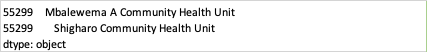

In [2]:
pcn_cleaned = pd.read_csv("clean_pcn_data.csv")
pcn_cleaned.shape

(21012, 5)

In [3]:
pcn_csv = pcn_cleaned.fillna("None")

In [4]:
pcn_csv.to_csv("pcn_csv.csv")

In [5]:
pcn_csv

,county,subcounty,hub,community_unit,facility
0,Uasin Gishu County,Ainabkoi Sub County,Burnt Forest Sub County Hospital,None,"Lifecare Hospital, Eldoret"
1,Uasin Gishu County,Ainabkoi Sub County,Burnt Forest Sub County Hospital,None,Eldoret Urosurgery Hospital Ltd
2,Uasin Gishu County,Ainabkoi Sub County,Burnt Forest Sub County Hospital,None,Equity Afia Eldoret Medical Centre
3,Uasin Gishu County,Ainabkoi Sub County,Burnt Forest Sub County Hospital,None,Eldoret Medical Specialist Centre
4,Uasin Gishu County,Ainabkoi Sub County,Burnt Forest Sub County Hospital,None,Oasis Heath Doctors Plaza Eldoret
...,...,...,...,...,...
21007,Samburu County,Samburu North Sub County,South Horr health Centre,Tuum Community Health Unit,Opiroi Health Centre
21008,Samburu County,Samburu North Sub County,South Horr health Centre,Opiroi Community Health Unit,Marti Health Centre
21009,Samburu County,Samburu North Sub County,South Horr health Centre,Marti Community Health Unit,Morijo Dispensary
21010,Samburu County,Samburu North Sub County,South Horr health Centre,Morijo Community Health Unit,Sererit Catholic Dispensary
